In [ ]:
# insert the following to the variable_definitions.py module to use this notebook

kinevars_1eNp = [
    ('reco_e', 7, (0, 3), r"Reconstructed Energy [GeV]"),
    ('n_protons_attach', 4, (0.5, 4.5), r"N protons at vertex"),
    ("theta1PlusTheta2", 8, (0, 4), "shr theta + trk theta"),
    ('cos_shr_theta', 6, (-1, 1), r"cos(shr theta)"),
    ("shr_phi", 5, (-3.14, 3.14), r"Shower $\phi$"),
    ('shr_energy_tot_cali', 6, (0, 1.8), r"Shower Energy (calibrated) [GeV]"),
    ('cos_trk_theta', 6, (-1, 1), r"cos(trk theta)"),
    ("trk_phi", 5, (-3.14, 3.14), r"Track $\phi$"),
    ("protonenergy", 6, (0, 0.6), "proton kinetic energy [GeV]"),
]

kinevars_1eNp_low_energy = [
    ('reco_e', 5, (0.1, 0.65), r"Reconstructed Energy [GeV]"),
    ('n_protons_attach', 4, (0.5, 4.5), r"N protons at vertex"),
    ("theta1PlusTheta2", 8, (0, 4), "shr theta + trk theta"),
    ('cos_shr_theta', 6, (-1, 1), r"cos(shr theta)"),
    ("shr_phi", 5, (-3.14, 3.14), r"Shower $\phi$"),
    ('shr_energy_tot_cali', 3, (0, 0.6), r"Shower Energy (calibrated) [GeV]"),
    ('cos_trk_theta', 6, (-1, 1), r"cos(trk theta)"),
    ("trk_phi", 5, (-3.14, 3.14), r"Track $\phi$"),
    ("protonenergy", 4, (0, 0.30), "proton kinetic energy [GeV]"),
]

kinevars_1e0p = [
    ('reco_e', 5, (0, 2), r"Reconstructed Energy [GeV]"),
    ('cos_shr_theta', 10, (-1, 1), r"cos(shr theta)"),
    ("shr_phi", 5, (-3.14, 3.14), r"Shower $\phi$"),
]

kinevars_1e0p_low_energy = [
    ('reco_e', 4, (0, 0.8), r"Reconstructed Energy [GeV]"),
    ('cos_shr_theta', 10, (-1, 1), r"cos(shr theta)"),
    ("shr_phi", 5, (-3.14, 3.14), r"Shower $\phi$"),
]

In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [3]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append("../../")
import data_loading as dl
from importlib import reload
reload(dl)

from microfit import run_plotter as rp
from microfit import histogram as hist

from microfit import variable_definitions as vdef
from microfit import selections

In [28]:
#RUN = ["1","2",“3_nocrt”,"3_crt","4b","4c","4d","5"]
RUN = ["3"]

rundata, mc_weights, data_pot = dl.load_runs(
    RUN,
    data="bnb",
    truth_filtered_sets=["nue"],
    loadpi0variables=True,
    loadshowervariables=True,
    loadrecoveryvars=True,
    loadsystematics=True,
    load_lee=True,
    blinded=False,
    load_crt_vars=True,
    enable_cache=True,
)

Loading run 3


# Plots for Np at all energies

In [ ]:
import matplotlib.pyplot as plt
from microfit import variable_definitions as vdef
from microfit import selections

selection = "NPBDT"
preselection = "NP"

for binning_def in vdef.kinevars_1eNp:
    # some binning definitions have more than 4 elements,
    # we ignore the last ones for now
    binning = hist.Binning.from_config(*binning_def[:4])
    print(binning_def)
    signal_generator = hist.RunHistGenerator(
        rundata,
        binning,
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        sideband_generator=None,
        uncertainty_defaults=None,
    )
    plotter = rp.RunHistPlotter(signal_generator)
    axes = plotter.plot(
        category_column="paper_category",
        include_multisim_errors=True,
        add_ext_error_floor=False,
        show_data_mc_ratio=True,
        show_chi_square=True,
    )
    
    plt.savefig(f'plots/PeLEEv2_plots/{selection}_{binning_def[0]}.pdf', bbox_inches='tight')
    plt.show()

# Plots for 0p at all energies

In [ ]:
selection = "ZPBDT_CRT"
preselection = "ZP"

for binning_def in vdef.kinevars_1e0p:
    # some binning definitions have more than 4 elements,
    # we ignore the last ones for now
    binning = hist.Binning.from_config(*binning_def[:4])
    print(binning_def)
    signal_generator = hist.RunHistGenerator(
        rundata,
        binning,
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        sideband_generator=None,
        uncertainty_defaults=None,
    )
    plotter = rp.RunHistPlotter(signal_generator)
    axes2 = plotter.plot(
        category_column="paper_category",
        include_multisim_errors=True,
        add_ext_error_floor=False,
        show_data_mc_ratio=True,
        show_chi_square=True,
    )
    
    plt.savefig(f'plots/PeLEEv2_plots/{selection}_{binning_def[0]}.pdf', bbox_inches='tight')
    plt.show()

# Filter the dataframes to keep events with reco_e < 0.65

In [31]:
filtered_rundata = {}
for key in rundata:
    filtered_rundata[key] = rundata[key].query('reco_e < 0.65')
all_df = pd.concat([df for k, df in filtered_rundata.items()])
all_rd = pd.concat([df for k, df in rundata.items()])

(array([    0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,  1021.,  7446., 10001., 11433., 12253., 12764.,
         6524.,     0.,     0.,     0.]),
 array([-1. , -0.9, -0.8, -0.7, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1,  0. ,
         0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8,  0.9,  1. ]),
 <BarContainer object of 20 artists>)

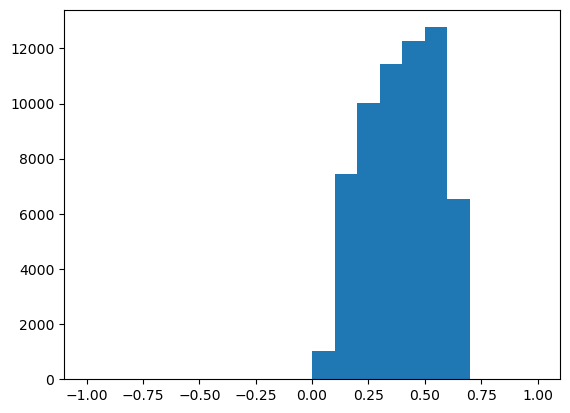

In [37]:
plt.hist(all_df['reco_e'], bins=20, range=(-1,1))

(array([    0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,  1021.,  7446., 10001., 11433., 12253., 12764.,
        12666., 12229., 11207., 10460.]),
 array([-1. , -0.9, -0.8, -0.7, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1,  0. ,
         0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8,  0.9,  1. ]),
 <BarContainer object of 20 artists>)

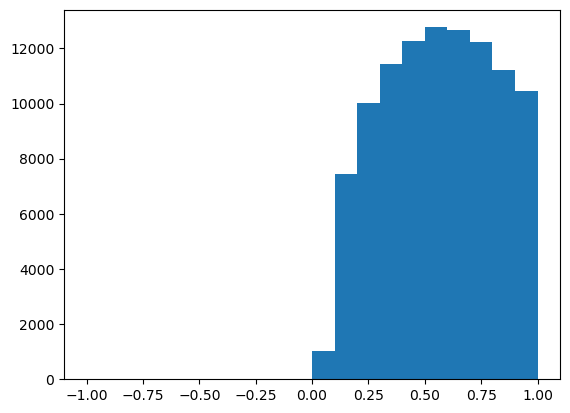

In [38]:
plt.hist(all_rd['reco_e'], bins=20, range=(-1,1))

In [26]:
for key, df in rundata.items():
    df.drop(df[df.reco_e > 0.65].index, inplace=True)

Double check if this worked by plotting the histogram below:

(array([    0.,     0.,  8467., 46451., 46562.]),
 array([-1. , -0.6, -0.2,  0.2,  0.6,  1. ]),
 <BarContainer object of 5 artists>)

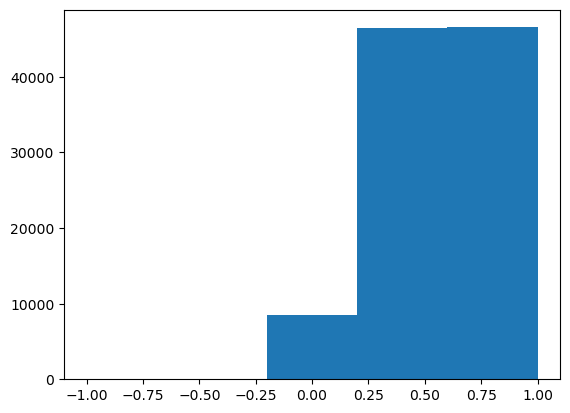

In [27]:
plt.hist(all_df['reco_e'], bins=5, range=(-1,1))

# Plots for Np at low energy

In [ ]:
selection = "NPBDT"
preselection = "NP"

for binning_def in vdef.kinevars_1eNp_low_energy:
    # some binning definitions have more than 4 elements,
    # we ignore the last ones for now
    binning = hist.Binning.from_config(*binning_def[:4])
    print(binning_def)
    signal_generator = hist.RunHistGenerator(
        filtered_rundata,
        binning,
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        sideband_generator=None,
        uncertainty_defaults=None,
    )
    plotter = rp.RunHistPlotter(signal_generator)
    axes3 = plotter.plot(
        category_column="paper_category",
        include_multisim_errors=True,
        add_ext_error_floor=False,
        show_data_mc_ratio=True,
        show_chi_square=True,
    )
    
    plt.savefig(f'plots/PeLEEv2_plots/low_energy_{selection}_{binning_def[0]}.pdf', bbox_inches='tight')
    plt.show()

# Plots for 0p at low energy

In [ ]:
selection = "ZPBDT_CRT"
preselection = "ZP"

for binning_def in vdef.kinevars_1e0p_low_energy:
    # some binning definitions have more than 4 elements,
    # we ignore the last ones for now
    binning = hist.Binning.from_config(*binning_def[:4])
    print(binning_def)
    signal_generator = hist.RunHistGenerator(
        filtered_rundata,
        binning,
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        sideband_generator=None,
        uncertainty_defaults=None,
    )
    plotter = rp.RunHistPlotter(signal_generator)
    axes4 = plotter.plot(
        category_column="paper_category",
        include_multisim_errors=True,
        add_ext_error_floor=False,
        show_data_mc_ratio=True,
        show_chi_square=True,
    )
    
    plt.savefig(f'plots/PeLEEv2_plots/low_energy_{selection}_{binning_def[0]}.pdf', bbox_inches='tight')
    plt.show()